<a href="https://colab.research.google.com/github/fahdchaib70-blip/AI-Product-Review-Intelligence/blob/model-part/project_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

PROJECT_DIR = "/content/AI-Product-Review-Intelligence"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder created:", PROJECT_DIR)

Project folder created: /content/AI-Product-Review-Intelligence


In [ ]:
!pip install -q torch transformers datasets scikit-learn pandas numpy matplotlib seaborn accelerate

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import logging
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ============================================================
# PROJECT PATHS + LOGGING
# ============================================================

PROJECT_DIR = "/content/AI-Product-Review-Intelligence"

MODEL_DIR = f"{PROJECT_DIR}/model/sentiment_distilbert"
LOG_DIR = f"{PROJECT_DIR}/logs"

# Create folders automatically
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# Configure logging
logging.basicConfig(
    filename=f"{LOG_DIR}/training.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Training started")

print("Model directory:", MODEL_DIR)
print("Log directory:", LOG_DIR)

Model directory: /content/AI-Product-Review-Intelligence/model/sentiment_distilbert
Log directory: /content/AI-Product-Review-Intelligence/logs


In [ ]:
# ============================================================
# GPU CHECK
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

if device == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not detected")
    print("Go to:")
    print("Runtime > Change runtime type > GPU")

logging.info(f"Device used: {device}")

Using device: cuda
GPU Name: Tesla T4


In [ ]:
# ============================================================
# LOAD FREE PRODUCT REVIEW DATASET
# Dataset: Amazon Polarity
# It contains product reviews + sentiment labels.
# ============================================================

DATASET_NAME = "amazon_polarity"

raw_dataset = load_dataset(
    DATASET_NAME,
    split="train[:20000]"
)

print(raw_dataset)
print(raw_dataset[0])

README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'title', 'content'],
    num_rows: 20000
})
{'label': 1, 'title': 'Stuning even for the non-gamer', 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}


In [ ]:
# ============================================================
# PREPARE DATASET
# Convert HuggingFace dataset to pandas DataFrame
# Keep only the columns we need:
# - review_text
# - sentiment
# ============================================================

df = pd.DataFrame(raw_dataset)

# Combine title + content to create one complete review text
df["review_text"] = df["title"].fillna("") + " " + df["content"].fillna("")

# Convert numeric labels to text labels
# amazon_polarity:
# 0 = negative
# 1 = positive
df["sentiment"] = df["label"].map({
    0: "negative",
    1: "positive"
})

# Keep only useful columns
df = df[["review_text", "sentiment"]]

# Remove empty or very short reviews
df = df[df["review_text"].str.len() >= 10]

# Reset index after cleaning
df = df.reset_index(drop=True)

print(df.head())
print(df["sentiment"].value_counts())
print("Dataset size:", len(df))

                                         review_text sentiment
0  Stuning even for the non-gamer This sound trac...  positive
1  The best soundtrack ever to anything. I'm read...  positive
2  Amazing! This soundtrack is my favorite music ...  positive
3  Excellent Soundtrack I truly like this soundtr...  positive
4  Remember, Pull Your Jaw Off The Floor After He...  positive
sentiment
positive    10257
negative     9743
Name: count, dtype: int64
Dataset size: 20000


In [ ]:
# ============================================================
# CREATE NUMERIC LABELS
# ============================================================

label2id = {
    "negative": 0,
    "positive": 1
}

id2label = {
    0: "negative",
    1: "positive"
}

# Convert sentiment text to numeric labels
df["label"] = df["sentiment"].map(label2id)

print(df.head())

print("\nUnique labels:")
print(df["label"].unique())

                                         review_text sentiment  label
0  Stuning even for the non-gamer This sound trac...  positive      1
1  The best soundtrack ever to anything. I'm read...  positive      1
2  Amazing! This soundtrack is my favorite music ...  positive      1
3  Excellent Soundtrack I truly like this soundtr...  positive      1
4  Remember, Pull Your Jaw Off The Floor After He...  positive      1

Unique labels:
[1 0]


In [ ]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

print("\nTraining distribution:")
print(train_df["sentiment"].value_counts())

print("\nValidation distribution:")
print(val_df["sentiment"].value_counts())

Training samples: 16000
Validation samples: 4000

Training distribution:
sentiment
positive    8206
negative    7794
Name: count, dtype: int64

Validation distribution:
sentiment
positive    2051
negative    1949
Name: count, dtype: int64


In [ ]:
# ============================================================
# CONVERT PANDAS DATAFRAMES TO HUGGINGFACE DATASETS
# ============================================================

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

print(train_dataset)
print(val_dataset)
print(train_dataset[0])

Dataset({
    features: ['review_text', 'sentiment', 'label'],
    num_rows: 16000
})
Dataset({
    features: ['review_text', 'sentiment', 'label'],
    num_rows: 4000
})
{'review_text': "Good insights If you're looking for good insights on criminal behaviour, this is it. I liked it and learned a few things I hadn't already explored.", 'sentiment': 'positive', 'label': 1}


In [ ]:
# ============================================================
# LOAD DISTILBERT TOKENIZER
# ============================================================

MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased


In [ ]:
# ============================================================
# TOKENIZATION FUNCTION
# ============================================================

def tokenize_batch(batch):
    """
    Converts text into tokens understandable by DistilBERT.

    truncation=True:
        Cuts very long reviews

    max_length=128:
        Keeps training fast and memory efficient
    """

    return tokenizer(
        batch["review_text"],
        truncation=True,
        max_length=128
    )

In [ ]:
# ============================================================
# APPLY TOKENIZATION
# ============================================================

train_tokenized = train_dataset.map(
    tokenize_batch,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_batch,
    batched=True
)

print(train_tokenized)
print(val_tokenized)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Dataset({
    features: ['review_text', 'sentiment', 'label', 'input_ids', 'attention_mask'],
    num_rows: 16000
})
Dataset({
    features: ['review_text', 'sentiment', 'label', 'input_ids', 'attention_mask'],
    num_rows: 4000
})


In [ ]:
# ============================================================
# REMOVE UNUSED COLUMNS
# ============================================================

train_tokenized = train_tokenized.remove_columns([
    "review_text",
    "sentiment"
])

val_tokenized = val_tokenized.remove_columns([
    "review_text",
    "sentiment"
])

print(train_tokenized)
print(val_tokenized)

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 16000
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 4000
})


In [ ]:
# ============================================================
# SET FORMAT TO PYTORCH
# ============================================================

train_tokenized.set_format("torch")
val_tokenized.set_format("torch")

print("Datasets are ready for PyTorch training.")
print(train_tokenized[0])

Datasets are ready for PyTorch training.
{'label': tensor(1), 'input_ids': tensor([  101,  2204, 20062,  2065,  2017,  1005,  2128,  2559,  2005,  2204,
        20062,  2006,  4735,  9164,  1010,  2023,  2003,  2009,  1012,  1045,
         4669,  2009,  1998,  4342,  1037,  2261,  2477,  1045,  2910,  1005,
         1056,  2525, 10641,  1012,   102]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [ ]:
# ============================================================
# LOAD DISTILBERT MODEL
# ============================================================

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

# Move model to GPU
model.to(device)

print("Model loaded successfully")
print("Device:", device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Device: cuda


In [ ]:
# ============================================================
# METRICS FUNCTION
# ============================================================

def compute_metrics(eval_pred):
    """
    Computes accuracy during evaluation.

    eval_pred contains:
    - logits: raw model outputs
    - labels: true labels
    """

    logits, labels = eval_pred

    # Convert raw logits into predicted class IDs
    predictions = np.argmax(logits, axis=1)

    # Calculate accuracy
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc
    }

In [ ]:
# ============================================================
# TRAINING ARGUMENTS
# ============================================================

training_args = TrainingArguments(
    output_dir=f"{PROJECT_DIR}/results",

    # Evaluate model after each epoch
    eval_strategy="epoch",

    # Save model checkpoint after each epoch
    save_strategy="epoch",

    # Learning rate for fine-tuning DistilBERT
    learning_rate=2e-5,

    # Batch size per GPU
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Few epochs for speed
    num_train_epochs=2,

    # Regularization to reduce overfitting
    weight_decay=0.01,

    # Logging folder
    logging_dir=LOG_DIR,
    logging_steps=50,

    # Keep best model according to validation accuracy
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    # Disable external reporting tools
    report_to="none"
)

print("Training arguments created successfully")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments created successfully


In [ ]:
# ============================================================
# DATA COLLATOR
# ============================================================

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Data collator ready")

Data collator ready


In [ ]:
# ============================================================
# CREATE TRAINER
# ============================================================

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer created successfully")

Trainer created successfully


In [ ]:
# ============================================================
# START TRAINING
# ============================================================

logging.info("Training started")

trainer.train()

logging.info("Training finished")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.202372,0.229353,0.924500
2,0.155105,0.250581,0.929750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [ ]:
# ============================================================
# FINAL EVALUATION
# ============================================================

eval_results = trainer.evaluate()

print("Final evaluation results:")
print(eval_results)

logging.info(f"Final evaluation results: {eval_results}")

Final evaluation results:
{'eval_loss': 0.2505814731121063, 'eval_accuracy': 0.92975, 'eval_runtime': 14.605, 'eval_samples_per_second': 273.878, 'eval_steps_per_second': 17.117, 'epoch': 2.0}


In [ ]:
# ============================================================
# GENERATE VALIDATION PREDICTIONS
# ============================================================

predictions_output = trainer.predict(val_tokenized)

y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=1)

print("Predictions generated successfully")
print("Number of predictions:", len(y_pred))

Predictions generated successfully
Number of predictions: 4000


In [ ]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=["negative", "positive"]
)

print(report)

              precision    recall  f1-score   support

    negative       0.93      0.93      0.93      1949
    positive       0.93      0.93      0.93      2051

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



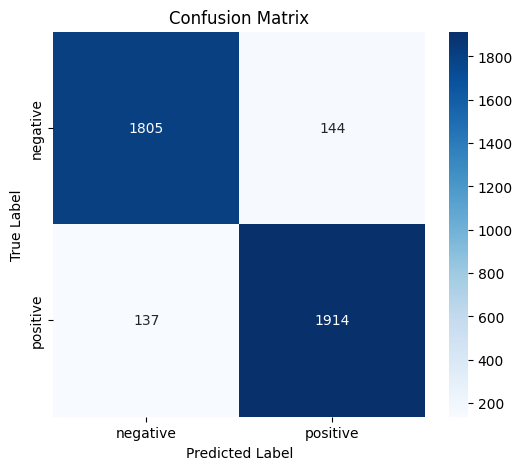

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ============================================================
# SAVE MODEL + TOKENIZER
# ============================================================

trainer.save_model(MODEL_DIR)

tokenizer.save_pretrained(MODEL_DIR)

print("Model and tokenizer saved successfully")
print("Saved in:", MODEL_DIR)

logging.info(f"Model saved in: {MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully
Saved in: /content/AI-Product-Review-Intelligence/model/sentiment_distilbert


In [ ]:
# ============================================================
# FINAL PREDICTION FUNCTION
# ============================================================

def predict_sentiment(text):
    """
    Predicts sentiment for a product review.

    Input:
        text (str)

    Output:
        {
            "label": "positive",
            "score": 0.95
        }
    """

    # Basic validation
    if not isinstance(text, str) or len(text.strip()) == 0:
        raise ValueError("Input text must be a non-empty string.")

    # Tokenize input text
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    # Move tensors to GPU
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Evaluation mode
    model.eval()

    # Disable gradients for inference
    with torch.no_grad():

        outputs = model(**inputs)

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        score, predicted_class_id = torch.max(
            probabilities,
            dim=1
        )

    # Convert numeric prediction into text label
    label = id2label[predicted_class_id.item()]

    return {
        "label": label,
        "score": round(score.item(), 4)
    }

In [ ]:
# ============================================================
# TEST PREDICTION FUNCTION
# ============================================================

test_review = "This product is amazing. The quality is excellent and I highly recommend it."

result = predict_sentiment(test_review)

print(result)

{'label': 'positive', 'score': 0.9966}


In [ ]:
import shutil

shutil.make_archive(
    "/content/sentiment_distilbert",
    'zip',
    "/content/AI-Product-Review-Intelligence/model/sentiment_distilbert"
)

print("ZIP created successfully")

ZIP created successfully
